In [359]:
import mytorch
import mytorch.layer
import mytorch.activation
import mytorch.optimizer
import mytorch.loss
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
# from torch.utils.data import DataLoader, TensorDataset

In [360]:
import numpy as np
FILE_PATH = r".\diabetes.csv"

In [361]:
# #don't change this cell
df = pd.read_csv(FILE_PATH, header=0)

# Rename Outcome to Diagnosis and convert to binary (already 0/1)
df = df.rename(columns={"Outcome": "Diagnosis"})

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [362]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Diagnosis                 768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [363]:
df[df['BMI'] == 0] = df['BMI'].mean()
df[df['BloodPressure'] == 0] = df['BloodPressure'].median()
df[df['Glucose'] == 0] = df['Glucose'].median()

C:\Users\asus\AppData\Local\Temp\ipykernel_8344\3054993464.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '31.992578124999998' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df[df['BMI'] == 0] = df['BMI'].mean()
C:\Users\asus\AppData\Local\Temp\ipykernel_8344\3054993464.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '31.992578124999998' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df[df['BMI'] == 0] = df['BMI'].mean()
C:\Users\asus\AppData\Local\Temp\ipykernel_8344\3054993464.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '31.992578124999998' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df[df['BMI'] ==

In [364]:
# don't change this cell
X = df.drop(columns=["Diagnosis"]).values
y = df["Diagnosis"].values
y = y.reshape(-1, 1) 

scaler= StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = mytorch.Tensor(X_train)
y_train = mytorch.Tensor(y_train)   

X_test = mytorch.Tensor(X_test)
y_test = mytorch.Tensor(y_test)

In [ ]:
          
def init_weights(layer, method='xavier'):
    """Initialize weights properly"""
    if hasattr(layer, 'W') and hasattr(layer.W, 'data'):
        fan_in, fan_out = layer.W.data.shape
        
        if method == 'xavier':
            limit = np.sqrt(6.0 / (fan_in + fan_out))
            layer.W.data = np.random.uniform(-limit, limit, (fan_in, fan_out))
        elif method == 'he':
            std = np.sqrt(2.0 / fan_in)
            layer.W.data = np.random.randn(fan_in, fan_out) * std
        
        if hasattr(layer, 'b') and hasattr(layer.b, 'data'):
            layer.b.data = np.zeros(layer.b.data.shape)
            
            
class MLP2(mytorch.Model):
    def __init__(self, input_size):
        super(MLP2, self).__init__()
        self.l1 = mytorch.layer.Linear(input_size, 64)
        self.l2 = mytorch.layer.Linear(64, 64)
        self.l3 = mytorch.layer.Linear(64, 16)
        self.l4 = mytorch.layer.Linear(16, 1)
        
        self.layers = [self.l1, self.l2, self.l3, self.l4]
        
        # for layer in self.layers:
        #     init_weights(layer, method='he')
        
        self.relu = mytorch.activation.relu
        self.sigmoid = mytorch.activation.sigmoid
    
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        x = self.relu(self.l3(x))
        x = self.sigmoid(self.l4(x))
        return x
        


In [366]:

# def check_gradients(model):
#     """بررسی اینکه gradient‌ها None نیستند"""
#     print("\n=== Gradient Check ===")
#     for i, layer in enumerate(model.layers):
#         if hasattr(layer, 'W'):
#             if hasattr(layer.W, 'grad'):
#                 grad_norm = np.linalg.norm(layer.W.grad.data) if layer.W.grad else 0
#                 print(f"Layer {i} W gradient norm: {grad_norm:.6f}")
#             if hasattr(layer, 'b') and hasattr(layer.b, 'grad'):
#                 grad_norm = np.linalg.norm(layer.b.grad.data) if layer.b.grad else 0
#                 print(f"Layer {i} b gradient norm: {grad_norm:.6f}")

# y_train_binary = mytorch.Tensor(y_train.data[:, 1].reshape(-1, 1)) 
y_test_binary = mytorch.Tensor(y_test.data)
input_size = X.shape[1]
model = MLP2(input_size)
criterion = mytorch.loss.ce.BinaryCrossEntropy
optimizer = mytorch.optimizer.Adam(model.parameters(), lr=0.0001)
NUM_EPOCHS = 40

In [367]:
train_accuracy_list = []
test_accuracy_list = []

batch_size = 64
# Training loop
for epoch in range(NUM_EPOCHS):

    # Training phase
    total = 0
    corrects = 0
    running_loss = 0.0

    for i in range(0, X_train.shape[0], batch_size):
        inputs = X_train[i:i+batch_size]
        labels = y_train[i:i+batch_size]
        
        # Forward pass
        outputs = model.forward(inputs)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        # Backward pass
        optimizer.zero_grad()
        grad = np.ones(loss.shape)
        loss.backward(grad)
        # loss.backward()
        optimizer.step()
        
        running_loss += loss.data.sum()
        # Calculate training accuracy
        pred = (outputs.data > 0.5).astype(float)
        corrects = (pred == labels.data).sum()
        total = labels.data.shape[0]
        
    epoch_loss = running_loss / total
    accuracy = corrects / total
    train_accuracy_list.append(accuracy)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}, Accuracy: {accuracy:.4f}")
    
    
    # # Evaluation phase (no gradient calculation needed)
    outputs_test = model.forward(X_test)
    pred_test = (outputs_test.data > 0.5).astype(float)
    correct = (pred_test == y_test_binary.data).sum()
    total = y_test_binary.data.shape[0]
    accuracy = correct / total
    test_accuracy_list.append(accuracy)
    
    print(f"Test Accuracy: {accuracy:.4f}", end="\n\n")

initialize cache
initialize cache
initialize cache
initialize cache
Epoch 1/40, Loss: 73.6364, Accuracy: 0.6316
Test Accuracy: 0.6104

Epoch 2/40, Loss: 63.3477, Accuracy: 0.6316
Test Accuracy: 0.6104

Epoch 3/40, Loss: 53.4667, Accuracy: 0.6053
Test Accuracy: 0.6104

Epoch 4/40, Loss: 42.9095, Accuracy: 0.6053
Test Accuracy: 0.6039

Epoch 5/40, Loss: 32.6284, Accuracy: 0.6053
Test Accuracy: 0.6039

Epoch 6/40, Loss: 23.6914, Accuracy: 0.6053
Test Accuracy: 0.6104

Epoch 7/40, Loss: 14.9398, Accuracy: 0.6053
Test Accuracy: 0.5974

Epoch 8/40, Loss: 7.1479, Accuracy: 0.6053
Test Accuracy: 0.5909

Epoch 9/40, Loss: 0.4983, Accuracy: 0.6053
Test Accuracy: 0.5779

Epoch 10/40, Loss: -5.9001, Accuracy: 0.6053
Test Accuracy: 0.5649

Epoch 11/40, Loss: -13.5542, Accuracy: 0.6579
Test Accuracy: 0.5649

Epoch 12/40, Loss: -22.7959, Accuracy: 0.6842
Test Accuracy: 0.5714

Epoch 13/40, Loss: -32.7352, Accuracy: 0.6842
Test Accuracy: 0.5779

Epoch 14/40, Loss: -43.0088, Accuracy: 0.6842
Test Accur

Test Accuracy: 0.6039

Epoch 23/40, Loss: -132.5553, Accuracy: 0.6842
Test Accuracy: 0.6104

Epoch 24/40, Loss: -143.9869, Accuracy: 0.6842
Test Accuracy: 0.6039

Epoch 25/40, Loss: -155.9024, Accuracy: 0.7105
Test Accuracy: 0.6039

Epoch 26/40, Loss: -168.3737, Accuracy: 0.7105
Test Accuracy: 0.5909

Epoch 27/40, Loss: -181.2386, Accuracy: 0.7105
Test Accuracy: 0.5974

Epoch 28/40, Loss: -194.6545, Accuracy: 0.7105
Test Accuracy: 0.5974

Epoch 29/40, Loss: -208.6956, Accuracy: 0.7105
Test Accuracy: 0.5909

Epoch 30/40, Loss: -223.4806, Accuracy: 0.7105
Test Accuracy: 0.5844

Epoch 31/40, Loss: -238.8925, Accuracy: 0.7105
Test Accuracy: 0.5974

Epoch 32/40, Loss: -255.0232, Accuracy: 0.7105
Test Accuracy: 0.6039

Epoch 33/40, Loss: -271.8759, Accuracy: 0.7105
Test Accuracy: 0.6039

Epoch 34/40, Loss: -289.5951, Accuracy: 0.7368
Test Accuracy: 0.6039

Epoch 35/40, Loss: -308.0761, Accuracy: 0.7368
Test Accuracy: 0.6039

Epoch 36/40, Loss: -327.5196, Accuracy: 0.7368
Test Accuracy: 0.590

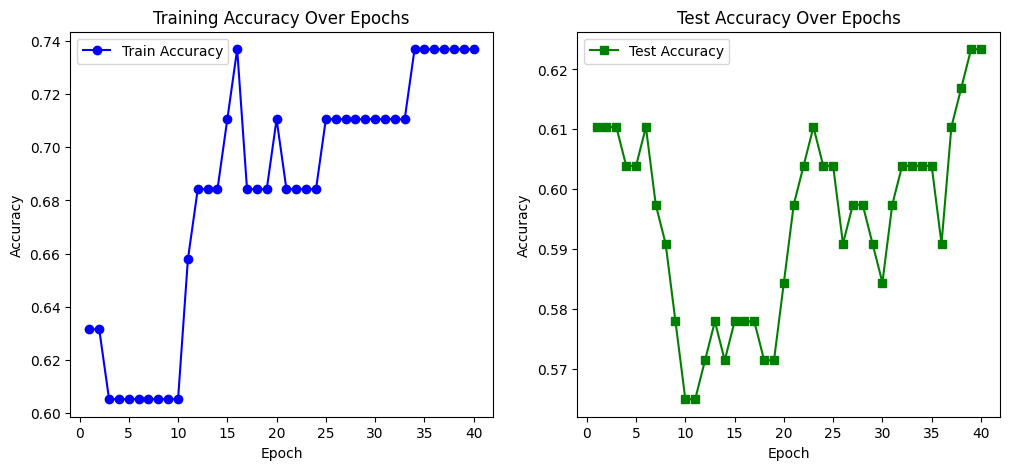

In [368]:
# don't change this cell
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_EPOCHS+1), train_accuracy_list, marker='o', linestyle='-', color='b', label="Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, NUM_EPOCHS+1), test_accuracy_list, marker='s', linestyle='-', color='g', label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy Over Epochs")
plt.legend()

plt.show()